# 4 - Normalização — escala uniforme para a GAIN

## Objetivo

Pôr todas as variáveis contínuas no mesmo intervalo `[-1, 1]` para que a magnitude de uma variável (Coliformes na ordem de 10⁶, Condutividade na ordem de 10⁴) não domine o gradiente da GAIN, persistindo os `MinMaxScaler` para inversão na Etapa 6.

## Posição na Etapa 2

Notebook **4 de 6** do pré-processamento. Consome `dataset_encoded.parquet` + `encoded_columns.json` (de `03_encoding.ipynb`). Entrega `dataset_normalizado.parquet` + `scalers.pkl` + `scaling_report.csv` para `05_split.ipynb`.

## Decisões registradas

### Range `[-1, 1]` (não `[0, 1]`)

Alinha-se à ativação `tanh` na camada de saída do gerador da GAIN. `tanh` tem gradiente melhor comportado em torno de zero do que `sigmoid`, sobretudo com features esparsamente preenchidas (Microcistinas com 605 NaN, Cianobactérias com 524).

### Fit em todo o dataset, antes do split

O `MinMaxScaler` é ajustado **sobre todos os 657 registros (2012–2025)**, antes do split temporal da Etapa 5. Existe um leakage suave de min/max do período futuro, mas a decisão é deliberada:

- O alvo desta GAIN é **imputação**, não predição — o leakage afeta apenas a escala, não a separação treino/teste do sinal a aprender.
- Os ranges físicos das variáveis (pH, OD, Temperatura, etc.) são governados por limites biogeoquímicos, não por época da coleta.
- A avaliação da GAIN se dá via **máscara artificial** sobre células `M=1` (Etapa 6), não via hold-out de valores fora do range — portanto o leakage de escala não vicia a métrica.

### `ano_norm` via rescale determinístico

Já chega em `[0, 1]` por construção de `02_features_temporais` (`(ano − 2012) / 13`). Aplicamos `2 · x − 1` (fórmula fechada, sem scaler ajustado) para mapear a `[-1, 1]` e alinhar com `tanh`. A inversão fica registrada em `transform_params.json` como `linear(a=2, b=-1)`.

## O que é tocado

| Grupo | Colunas | Tratamento |
|---|---|---|
| Numéricas (13) | DBO, OD, Nitrato, NH₃, P-Total, Condutividade, pH, Turbidez, Temp. Água, SST, Coliformes, Cianobactérias, Microcistinas | `MinMaxScaler(-1, 1)` por coluna, persistido |
| Escalar contínuo | `dias_desde_inicio` | `MinMaxScaler(-1, 1)`, persistido |
| Determinístico | `ano_norm` | `2x − 1` (sem scaler) |
| Bypass — já em escala adequada | `Mes_sin`, `Mes_cos` (cíclicas em `[-1, 1]`), `umido` (binária), 8 `est_*` (binárias), 18 `<Var>_LD_*` (binárias) | nada |
| Bypass — fora do vetor da GAIN | `Data`, `Ano_int` | nada (auditoria/split) |


## Setup

Imports + caminhos relativos a `Code/3 - Preprocessing/04_normalizacao.ipynb`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", context="notebook")

IN_PARQUET      = Path("../../Data/ProcessedData/dataset_encoded.parquet")
IN_COLUMNS_JSON = Path("../../Data/ProcessedData/encoded_columns.json")
IN_PARAMS_JSON  = Path("../../Data/ProcessedData/transform_params.json")

OUT_PARQUET = Path("../../Data/ProcessedData/dataset_normalizado.parquet")
OUT_SCALERS = Path("../../Data/ProcessedData/scalers.pkl")
OUT_REPORT  = Path("../../Data/ProcessedData/scaling_report.csv")
FIG_DIR     = Path("../../Data/Figures/02_Preprocessing/figuras")
FIG_DIR.mkdir(parents=True, exist_ok=True)

REVERSIBILIDADE_TOL = 1e-6
RANGE_EPS           = 1e-9  # folga numérica para conferir min/max
ANO_NORM_LINEAR     = {"tipo": "linear", "a": 2.0, "b": -1.0}

# MinMaxScaler ignora NaN no fit a partir de sklearn 1.0; fail-fast caso o ambiente seja antigo
assert tuple(int(x) for x in sklearn.__version__.split(".")[:2]) >= (1, 0), (
    f"sklearn {sklearn.__version__} < 1.0 — MinMaxScaler pode não preservar NaN."
)
print(f"sklearn {sklearn.__version__} — OK.")

sklearn 1.8.0 — OK.


## Carregamento

Lê o dataset encoded, o índice de colunas (gerado em `03_encoding`) e os parâmetros de transformação (gerados em `01_transformacoes` — vamos **acrescentar** a entrada de `ano_norm` ao final).

In [2]:
df = pd.read_parquet(IN_PARQUET)
print(f"Shape de entrada: {df.shape}")

with open(IN_COLUMNS_JSON, "r", encoding="utf-8") as f:
    encoded_columns = json.load(f)

with open(IN_PARAMS_JSON, "r", encoding="utf-8") as f:
    transform_params = json.load(f)

# Fail-fast: o parquet precisa ter exatamente as colunas listadas em encoded_columns.ordem_completa
esperadas = encoded_columns["ordem_completa"]
faltando = [c for c in esperadas if c not in df.columns]
extras   = [c for c in df.columns if c not in esperadas]
assert not faltando, f"Colunas esperadas ausentes no parquet: {faltando}"
assert not extras,   f"Colunas extras no parquet (não previstas no JSON): {extras}"
print(f"Estrutura consistente com encoded_columns.json: {len(esperadas)} colunas.")

Shape de entrada: (657, 46)
Estrutura consistente com encoded_columns.json: 46 colunas.


## Categorização das colunas

Quatro grupos explícitos a partir de `encoded_columns.json` — facilita auditoria e evita normalizar acidentalmente uma coluna one-hot.

In [3]:
cols_para_scaler = encoded_columns["numericas"] + ["dias_desde_inicio"]
cols_rescale_deterministico = ["ano_norm"]
cols_bypass_escala = (
    ["Mes_sin", "Mes_cos", "umido"]
    + encoded_columns["estacao_onehot"]
    + encoded_columns["ld_onehot"]
)
cols_bypass_audit = encoded_columns["identificadores"]

# Sanidade: a união dos 4 grupos é exatamente o conjunto de colunas do dataframe
todas = set(cols_para_scaler) | set(cols_rescale_deterministico) | set(cols_bypass_escala) | set(cols_bypass_audit)
assert todas == set(df.columns), (
    f"Cobertura incompleta. Faltando: {set(df.columns) - todas}. Sobrando: {todas - set(df.columns)}"
)

print(f"MinMaxScaler ajustado em ({len(cols_para_scaler)}): {cols_para_scaler}")
print(f"\nRescale determinístico ({len(cols_rescale_deterministico)}): {cols_rescale_deterministico}")
print(f"\nBypass — escala já adequada ({len(cols_bypass_escala)}): {len(encoded_columns['estacao_onehot'])} est_* + {len(encoded_columns['ld_onehot'])} _LD_* + Mes_sin/cos + umido")
print(f"\nBypass — fora do vetor da GAIN ({len(cols_bypass_audit)}): {cols_bypass_audit}")

MinMaxScaler ajustado em (14): ['DBO', 'OD', 'Nitrato', 'Nitrogênio Amoniacal Total', 'Fósforo Total', 'Condutividade', 'pH', 'Turbidez', 'Temperatura da Água', 'Sólidos Suspensos Totais', 'Coliformes Termotolerantes', 'Cianobacterias', 'Microcistinas', 'dias_desde_inicio']

Rescale determinístico (1): ['ano_norm']

Bypass — escala já adequada (29): 8 est_* + 18 _LD_* + Mes_sin/cos + umido

Bypass — fora do vetor da GAIN (2): ['Data', 'Ano_int']


## Rescale determinístico de `ano_norm`

`ano_norm` chega em `[0, 1]` por construção. Aplicamos `2x − 1` direto — fórmula fechada, sem scaler. A inversão é `(x + 1) / 2`, registrada em `transform_params.json` para a Etapa 6.

In [4]:
ano_norm_antes_min = float(df["ano_norm"].min())
ano_norm_antes_max = float(df["ano_norm"].max())
assert 0.0 - RANGE_EPS <= ano_norm_antes_min and ano_norm_antes_max <= 1.0 + RANGE_EPS, (
    f"ano_norm fora de [0,1] no input: [{ano_norm_antes_min}, {ano_norm_antes_max}]"
)

df["ano_norm"] = 2.0 * df["ano_norm"] - 1.0

print(f"ano_norm: [{ano_norm_antes_min:.4f}, {ano_norm_antes_max:.4f}] → "
      f"[{df['ano_norm'].min():.4f}, {df['ano_norm'].max():.4f}]")

ano_norm: [0.0000, 1.0000] → [-1.0000, 1.0000]


## Ajuste e aplicação dos `MinMaxScaler`

Loop sobre as 14 colunas (13 variáveis numéricas + `dias_desde_inicio`):

1. `scaler.fit(df[[col]])` — sklearn ≥ 1.0 ignora NaN no `fit` (computa `min`/`max` apenas sobre valores válidos).
2. `scaler.transform(df[[col]])` — NaN é propagado como NaN no output.
3. O scaler é armazenado em `scalers[col]` para `inverse_transform` na Etapa 6.

**Um scaler por variável** (não um único multi-coluna): facilita inversão seletiva e evita acoplamento entre features.

In [5]:
scalers: dict[str, MinMaxScaler] = {}
linhas_fit = []

for col in cols_para_scaler:
    serie_antes = df[col]
    min_orig = float(serie_antes.min(skipna=True))
    max_orig = float(serie_antes.max(skipna=True))
    n_nan_antes = int(serie_antes.isna().sum())

    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(df[[col]])
    df[col] = scaler.transform(df[[col]]).flatten()

    serie_depois = df[col]
    linhas_fit.append({
        "coluna":         col,
        "min_orig":       min_orig,
        "max_orig":       max_orig,
        "min_norm":       float(serie_depois.min(skipna=True)),
        "max_norm":       float(serie_depois.max(skipna=True)),
        "n_nan_antes":    n_nan_antes,
        "n_nan_depois":   int(serie_depois.isna().sum()),
    })
    scalers[col] = scaler

tab_fit = pd.DataFrame(linhas_fit).set_index("coluna")
tab_fit

,min_orig,max_orig,min_norm,max_norm,n_nan_antes,n_nan_depois
coluna,,,,,,
DBO,0.0000,6.3125,-1.0000,1.0000,15,15
OD,0.0000,5.2474,-1.0000,1.0000,22,22
Nitrato,-13.0203,1.5143,-1.0000,1.0000,320,320
Nitrogênio Amoniacal Total,0.0000,3.3231,-1.0000,1.0000,160,160
Fósforo Total,-4.4812,4.5686,-1.0000,1.0000,33,33
Condutividade,4.1447,347.4314,-1.0000,1.0000,22,22
pH,6.0000,10.5000,-1.0000,1.0000,18,18
Turbidez,-0.7897,7.9455,-1.0000,1.0000,26,26
Temperatura da Água,16.0000,36.0000,-1.0000,1.0000,28,28


## Sanidade

Para cada coluna escalada, conferir:

- `min ∈ [-1 − ε, -1 + ε]` e `max ∈ [1 − ε, 1 + ε]` (com `ε = 1e-9`).
- Número de NaN igual antes e depois.

Em paralelo, conferir que as colunas **bypass** continuam idênticas ao input (proteção contra modificação acidental). Para isso, recarregamos o parquet original e comparamos célula-a-célula.

In [6]:
# 1) Min/max e NaN nas colunas escaladas
problemas = []
for _, row in tab_fit.iterrows():
    if not (-1 - RANGE_EPS <= row["min_norm"] <= -1 + RANGE_EPS):
        problemas.append((row.name, "min_norm fora de -1", row["min_norm"]))
    if not (1 - RANGE_EPS <= row["max_norm"] <= 1 + RANGE_EPS):
        problemas.append((row.name, "max_norm fora de +1", row["max_norm"]))
    if row["n_nan_antes"] != row["n_nan_depois"]:
        problemas.append((row.name, "n_nan diverge", (row["n_nan_antes"], row["n_nan_depois"])))

assert not problemas, f"Falhas de sanidade: {problemas}"
print(f"OK — {len(tab_fit)} colunas escaladas dentro de [-1, 1] com NaN preservado.")

# 2) Bypass: confronto com input original
df_input = pd.read_parquet(IN_PARQUET)
for col in cols_bypass_escala + cols_bypass_audit:
    if not df_input[col].equals(df[col]):
        problemas.append((col, "bypass tocado", None))
assert not problemas, f"Colunas bypass foram alteradas: {problemas}"
print(f"OK — {len(cols_bypass_escala) + len(cols_bypass_audit)} colunas bypass intactas.")

# 3) ano_norm está em [-1, 1]
ano_min, ano_max = float(df["ano_norm"].min()), float(df["ano_norm"].max())
assert -1 - RANGE_EPS <= ano_min and ano_max <= 1 + RANGE_EPS, f"ano_norm fora de [-1, 1]: [{ano_min}, {ano_max}]"
print(f"OK — ano_norm em [{ano_min:.4f}, {ano_max:.4f}].")

OK — 14 colunas escaladas dentro de [-1, 1] com NaN preservado.
OK — 31 colunas bypass intactas.
OK — ano_norm em [-1.0000, 1.0000].


## Inversibilidade

Para cada coluna escalada, sortear 10 valores não-NaN, aplicar `inverse_transform` e verificar `max |x − x_recovered| < 1e-6` (critério do `README.md` da Etapa 2). Repetir o teste para `ano_norm` com a inversão `(x + 1) / 2`.

In [7]:
rng = np.random.default_rng(seed=42)
rev_rows = []

for col, scaler in scalers.items():
    serie_norm = df[col].dropna()
    if len(serie_norm) == 0:
        continue
    idx = rng.choice(serie_norm.index, size=min(10, len(serie_norm)), replace=False)
    x_norm = df.loc[idx, col].to_numpy().reshape(-1, 1)
    x_inv  = scaler.inverse_transform(x_norm).flatten()
    x_orig = df_input.loc[idx, col].to_numpy()
    err = float(np.max(np.abs(x_orig - x_inv)))
    rev_rows.append({"coluna": col, "err_max": err, "ok": err < REVERSIBILIDADE_TOL})

# ano_norm: inversão = (x + 1) / 2
x_orig_ano = df_input["ano_norm"].sample(10, random_state=42).to_numpy()
x_norm_ano = 2.0 * x_orig_ano - 1.0
x_inv_ano  = (x_norm_ano + 1.0) / 2.0
err_ano = float(np.max(np.abs(x_orig_ano - x_inv_ano)))
rev_rows.append({"coluna": "ano_norm", "err_max": err_ano, "ok": err_ano < REVERSIBILIDADE_TOL})

tab_rev = pd.DataFrame(rev_rows).set_index("coluna")
todas_ok = bool(tab_rev["ok"].all())
print(f"Inversão dentro de {REVERSIBILIDADE_TOL}: {todas_ok}")
assert todas_ok, f"Falha de reversibilidade em: {tab_rev[~tab_rev['ok']].index.tolist()}"
tab_rev

Inversão dentro de 1e-06: True


,err_max,ok
coluna,,
DBO,0.0000,True
OD,0.0000,True
Nitrato,0.0000,True
Nitrogênio Amoniacal Total,0.0000,True
Fósforo Total,0.0000,True
Condutividade,0.0000,True
pH,0.0000,True
Turbidez,0.0000,True
Temperatura da Água,0.0000,True


## Comparação visual

Histogramas antes/depois para 4 variáveis com escalas mais díspares no espaço transformado — confirma que a distribuição interna preserva forma, só muda a faixa.

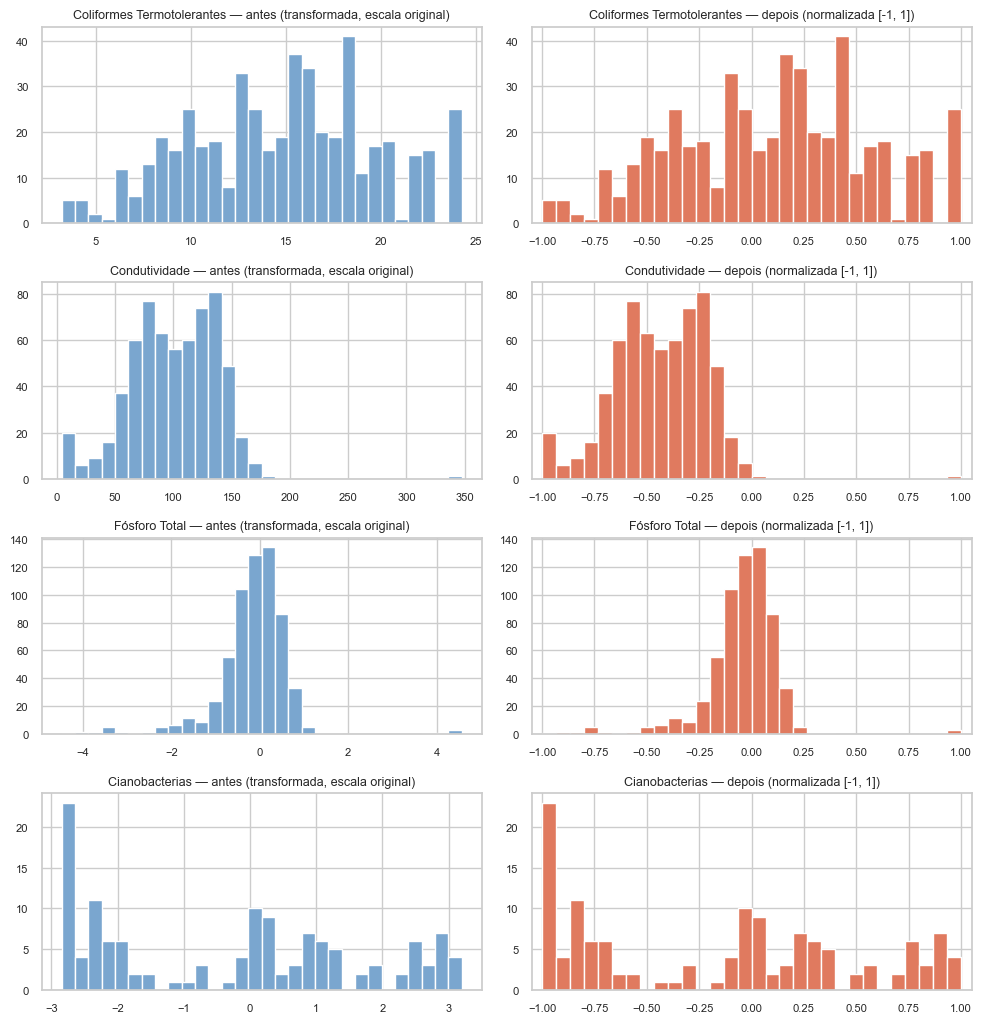

In [8]:
vars_visual = ["Coliformes Termotolerantes", "Condutividade", "Fósforo Total", "Cianobacterias"]

fig, axes = plt.subplots(len(vars_visual), 2, figsize=(10, 2.6 * len(vars_visual)))
for i, v in enumerate(vars_visual):
    ax_a, ax_d = axes[i, 0], axes[i, 1]
    x_antes  = df_input[v].dropna().to_numpy()
    x_depois = df[v].dropna().to_numpy()

    ax_a.hist(x_antes, bins=30, color="#7aa6cf", edgecolor="white")
    ax_a.set_title(f"{v} — antes (transformada, escala original)", fontsize=9)
    ax_a.tick_params(labelsize=8)

    ax_d.hist(x_depois, bins=30, color="#e07a5f", edgecolor="white")
    ax_d.set_title(f"{v} — depois (normalizada [-1, 1])", fontsize=9)
    ax_d.set_xlim(-1.05, 1.05)
    ax_d.tick_params(labelsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "normalizacao_antes_depois.png", dpi=150)
plt.show()

## Auditoria de outliers dominando a escala

Se uma variável tem outlier extremo, o `MinMaxScaler` espreme o grosso da distribuição num intervalo pequeno em torno de zero. Critério: se o **percentil 95** do valor absoluto normalizado fica `< 0,5`, registramos como alerta para a Etapa 4 (a GAIN pode ter dificuldade em diferenciar valores comprimidos).

In [9]:
alertas = []
for col in cols_para_scaler:
    p95 = float(df[col].abs().quantile(0.95))
    if p95 < 0.5:
        alertas.append({"coluna": col, "p95_abs_norm": p95})

if alertas:
    print("Variáveis com p95(|x_norm|) < 0,5 — outlier extremo comprimindo a escala:")
    print(pd.DataFrame(alertas).set_index("coluna"))
    print("\n→ Registrar atenção em 04_GAIN/03_diagnostico.ipynb para essas variáveis.")
else:
    print("Nenhuma variável com escala dominada por outlier (p95 ≥ 0,5 em todas).")

Variáveis com p95(|x_norm|) < 0,5 — outlier extremo comprimindo a escala:
               p95_abs_norm
coluna                     
Fósforo Total        0.4048

→ Registrar atenção em 04_GAIN/03_diagnostico.ipynb para essas variáveis.


## Persistência

Quatro artefatos:

- `dataset_normalizado.parquet` — dataframe com as 14 colunas escaladas + `ano_norm` rescalado.
- `scalers.pkl` — dicionário `{coluna: MinMaxScaler}` via `joblib`.
- `scaling_report.csv` — tabela de auditoria `coluna × min/max antes/depois × NaN`.
- `transform_params.json` — **atualizado** com a entrada `ano_norm` (rescale linear).

In [10]:
# Parquet
df.to_parquet(OUT_PARQUET, index=False)

# Scalers
joblib.dump(scalers, OUT_SCALERS)

# Relatório
tab_fit.to_csv(OUT_REPORT, encoding="utf-8")

# transform_params.json atualizado
transform_params["ano_norm"] = ANO_NORM_LINEAR
with open(IN_PARAMS_JSON, "w", encoding="utf-8") as f:
    json.dump(transform_params, f, ensure_ascii=False, indent=2)

print(f"Salvo: {OUT_PARQUET} ({OUT_PARQUET.stat().st_size} bytes)")
print(f"Salvo: {OUT_SCALERS} ({OUT_SCALERS.stat().st_size} bytes)")
print(f"Salvo: {OUT_REPORT}  ({OUT_REPORT.stat().st_size} bytes)")
print(f"Atualizado: {IN_PARAMS_JSON} (+ chave 'ano_norm')")

Salvo: ..\..\Data\ProcessedData\dataset_normalizado.parquet (57822 bytes)
Salvo: ..\..\Data\ProcessedData\scalers.pkl (8553 bytes)
Salvo: ..\..\Data\ProcessedData\scaling_report.csv  (928 bytes)
Atualizado: ..\..\Data\ProcessedData\transform_params.json (+ chave 'ano_norm')


## Síntese final

- **15 colunas escaladas** para `[-1, 1]`: 13 numéricas + `dias_desde_inicio` (via `MinMaxScaler`) + `ano_norm` (via rescale linear `2x − 1`).
- **27 colunas bypass intactas**: `Data`, `Ano_int`, `Mes_sin`, `Mes_cos`, `umido`, 8 `est_*`, 18 `<Var>_LD_*`.
- **Shape final**: 657 × 46 (idêntico ao input — apenas valores foram reescalados).
- **NaN preservados** em todas as colunas escaladas (precondição para a máscara `M` na Etapa 6).
- **Inversibilidade** verificada com erro máximo `< 1e-6` em todas as 14 colunas + `ano_norm`.

### Aviso para a Etapa 6

A sequência **obrigatória** de inversão (do espaço da GAIN → escala original) é:

1. **Desnormalizar** via `scalers.pkl` (`scaler.inverse_transform`).
2. **Inverter `ano_norm`** via `transform_params['ano_norm']` (`(x + 1) / 2`).
3. **Inverter Box-Cox / Yeo-Johnson** via `transform_params.json` (helper `inverter_transformacao` de `01_transformacoes`).

Sair dessa ordem produz valores fora da escala física esperada.

### Decisão deliberada registrada

O `MinMaxScaler` foi ajustado em todo o dataset (incluindo val/test futuros) — leakage suave consciente, justificável porque a GAIN é imputadora e a avaliação se dá via máscara artificial, não via hold-out de valores extremos. Revisitar **somente** se o objetivo mudar para predição/forecast.

### Próximo notebook

`05_split.ipynb` — split temporal (treino ≤ 2022, val 2023, teste ≥ 2024).